In [ ]:
!pip install mvlearn==0.5.0 --no-deps
!pip install scikit-learn scipy numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.4 MB/s eta 0:00:00


In [ ]:
pip install POT pymanopt autograd scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
from mvlearn.datasets import load_UCImultifeature

# ============================================================
# CONFIGURAÇÃO DO DATASET A SALVAR
# ============================================================

RANDOM_SEED = 5

N_CLASSES = 5                 # classes 0..N_CLASSES-1
VIEWS = [0, 1]                # None = todas
N_SAMPLES_PER_CLASS = 200     # None = todas

SAVE_PATH = "ucimultifeature_bary_gwmds.npz"


# ============================================================
# CARREGA DATASET COMPLETO
# ============================================================

Xs, labels = load_UCImultifeature()
rng = np.random.default_rng(RANDOM_SEED)

# Views
all_views = list(range(len(Xs)))
if VIEWS is None:
    used_views = all_views
else:
    used_views = list(VIEWS)

# Classes
classes = np.arange(N_CLASSES)
mask = np.isin(labels, classes)
idx = np.where(mask)[0]

# Amostragem balanceada por classe
if N_SAMPLES_PER_CLASS is not None:
    chosen = []
    for c in classes:
        idx_c = idx[labels[idx] == c]
        if len(idx_c) < N_SAMPLES_PER_CLASS:
            raise ValueError(
                f"Classe {c} tem {len(idx_c)} amostras, "
                f"mas você pediu {N_SAMPLES_PER_CLASS}."
            )
        chosen.append(
            rng.choice(idx_c, size=N_SAMPLES_PER_CLASS, replace=False)
        )
    idx = np.concatenate(chosen)
    idx = rng.permutation(idx)

# Subconjunto final
Xs_sub = [Xs[v][idx].astype(np.float64) for v in used_views]
labels_sub = labels[idx].astype(np.int64)

print("Dataset salvo com:")
print("Views usadas:", used_views)
print("Nº de amostras:", Xs_sub[0].shape[0])
print("Dimensões por view:", [X.shape[1] for X in Xs_sub])
print("Classes:", np.unique(labels_sub))


# ============================================================
# SALVA EM .NPZ (PRONTO PARA bary-GWMDS-C)
# ============================================================

save_dict = {
    "labels": labels_sub,
    "views": np.array(used_views),
    "n_classes": N_CLASSES
}

for i, X in enumerate(Xs_sub):
    save_dict[f"X_view_{i}"] = X

np.savez(SAVE_PATH, **save_dict)

print(f"\nArquivo salvo em: {SAVE_PATH}")


Dataset salvo com:
Views usadas: [0, 1]
Nº de amostras: 1000
Dimensões por view: [76, 216]
Classes: [0 1 2 3 4]

Arquivo salvo em: ucimultifeature_bary_gwmds.npz


### **Mean-GWMDS-C**





In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.manifold import Isomap
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs, make_moons, make_swiss_roll, make_s_curve

import ot  # POT (Python Optimal Transport)

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
import torch
import ot
from typing import Literal, Callable, Tuple, List, Optional
import numpy as np
from tqdm import tqdm


class MeanGWMDS(torch.nn.Module):
    """
    Mean-GWMDS:
    Multi-view Gromov-Wasserstein MDS with distance-mean consensus.

    Key fix:
    Before averaging distances across views, each view-wise distance
    matrix is normalized to the same scale (default: divide by off-diagonal median).
    This avoids one view dominating the mean just because its distances
    are larger in magnitude.
    """

    def __init__(
        self,
        n_clusters: Optional[int],
        n_components: int = 2,
        reg_e: float = 0.0,
        init: Literal['randn', 'rand', 'pca'] = 'randn',
        optimizer_name: Literal['sgd', 'adam'] = 'adam',
        learning_rate: float = 0.1,
        metric_fn: Optional[Callable] = None,
        precomputed_metric: bool = False,
        learn_prototype_weights: bool = True,
        device: torch.device | str = 'cpu',
        view_weights: Optional[torch.Tensor] = None,  # pesos da média (opcional)

        # NEW: normalize DX per view before averaging
        normalize_dx: Literal['none', 'median', 'mean', 'fro'] = 'median',
        symmetrize_dx: bool = True,
        zero_diagonal: bool = True,
        eps: float = 1e-12,

        # Optional: run GW in float64 for stability
        gw_double: bool = True
    ):
        super(MeanGWMDS, self).__init__()

        self.n_clusters = n_clusters
        self.n_components = n_components
        self.init = init.lower()
        self.learning_rate = learning_rate
        self.embeddings_ = None
        self.fitted = False
        self.optimizer_name = optimizer_name.lower()
        self.precomputed_metric = precomputed_metric
        self.reg_e = reg_e
        self.device = device
        self.learn_prototype_weights = learn_prototype_weights
        self.view_weights = view_weights

        # NEW
        self.normalize_dx = normalize_dx
        self.symmetrize_dx = symmetrize_dx
        self.zero_diagonal = zero_diagonal
        self.eps = eps
        self.gw_double = gw_double

        if metric_fn is None:
            self.metric_fn = torch.cdist
        else:
            self.metric_fn = metric_fn

        self.history = {'loss': [], 'embeddings': []}

        # Interpretability
        self.transport_plans_ = None   # único T (replicado por view)
        self.prototype_weights_ = None
        self.sample_weights_ = None
        self.consensus_distance_ = None

    # ---------------------------------------------------------
    # Utils
    # ---------------------------------------------------------
    def _sanitize_dx(self, DX: torch.Tensor) -> torch.Tensor:
        """Optionally symmetrize and/or zero the diagonal."""
        if self.symmetrize_dx:
            DX = 0.5 * (DX + DX.T)
        if self.zero_diagonal:
            DX = DX.clone()
            DX.fill_diagonal_(0.0)
        return DX

    def _scale_dx(self, DX: torch.Tensor) -> torch.Tensor:
        """
        Normalize a distance matrix so different views have comparable scales.
        Default is median of off-diagonal entries (robust).
        """
        if self.normalize_dx == 'none':
            return DX

        n = DX.shape[0]
        mask = ~torch.eye(n, dtype=torch.bool, device=DX.device)
        vals = DX[mask]

        if self.normalize_dx == 'median':
            s = vals.median()
        elif self.normalize_dx == 'mean':
            s = vals.mean()
        elif self.normalize_dx == 'fro':
            s = torch.linalg.norm(DX, ord='fro')
        else:
            raise ValueError("normalize_dx must be one of: 'none', 'median', 'mean', 'fro'")

        return DX / (s + self.eps)

    def _mean_distance(self, DX_list: List[torch.Tensor]) -> torch.Tensor:
        """
        Compute mean (or weighted mean) of *normalized* distance matrices.
        """
        # sanitize + normalize each view
        DXn_list = []
        for DX in DX_list:
            DX = self._sanitize_dx(DX)
            DX = self._scale_dx(DX)
            DXn_list.append(DX)

        if self.view_weights is None:
            DX_bar = torch.stack(DXn_list, dim=0).mean(dim=0)
        else:
            w = self.view_weights.to(DXn_list[0].device).to(DXn_list[0].dtype).reshape(-1)
            w = w / (w.sum() + self.eps)
            if w.numel() != len(DXn_list):
                raise ValueError(f"view_weights deve ter shape (V,), mas recebeu {w.shape} para V={len(DXn_list)}")

            DX_bar = torch.zeros_like(DXn_list[0])
            for wi, DXi in zip(w, DXn_list):
                DX_bar = DX_bar + wi * DXi

        # final sanitize (garante simetria/diagonal)
        DX_bar = self._sanitize_dx(DX_bar)
        return DX_bar

    # ---------------------------------------------------------
    # GW core
    # ---------------------------------------------------------
    def compute_srgw_loss(
        self,
        DX: torch.Tensor,
        DY: torch.Tensor,
        p: torch.Tensor,
        q: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        with torch.no_grad():
            if self.reg_e <= 0.0:
                T = ot.gromov.gromov_wasserstein(
                    C1=DX, C2=DY, p=p, q=q,
                    loss_fun='square_loss', tol=1e-5, verbose=False
                )
            else:
                T = ot.gromov.entropic_gromov_wasserstein(
                    C1=DX, C2=DY, p=p, q=q,
                    epsilon=self.reg_e, loss_fun='square_loss',
                    tol=1e-5, verbose=False
                )

        constC, hX, hY = ot.gromov._utils.init_matrix(
            DX, DY, p, q, loss_fun='square_loss'
        )
        loss = ot.gromov._utils.gwloss(constC, hX, hY, T)
        return loss, T

    # ---------------------------------------------------------
    # Fit
    # ---------------------------------------------------------
    def fit(self, X: List[torch.Tensor], n_iter: int = 100) -> 'MeanGWMDS':

        if not isinstance(X, list) or len(X) == 0:
            raise ValueError("X deve ser uma lista não-vazia de tensores (uma view por elemento).")

        n_samples = X[0].shape[0]
        for v, Xi in enumerate(X):
            if Xi.shape[0] != n_samples:
                raise ValueError(f"Todas as views devem ter o mesmo N. View {v} tem {Xi.shape[0]}, esperado {n_samples}.")

        n_prototypes = n_samples if self.n_clusters is None else self.n_clusters

        # Embedding init
        if self.init == 'randn':
            self.embeddings_ = torch.randn(n_prototypes, self.n_components, device=self.device)
        else:
            self.embeddings_ = torch.rand(n_prototypes, self.n_components, device=self.device)

        self.embeddings_.requires_grad = True

        # Prototype weights
        if self.learn_prototype_weights:
            self._log_weights = torch.zeros(n_prototypes, device=self.device)
            self._log_weights.requires_grad = True
            params = [self.embeddings_, self._log_weights]
        else:
            self._log_weights = None
            params = [self.embeddings_]

        self.sample_weights_ = torch.ones(n_samples, device=self.device) / n_samples

        # Optimizer
        if self.optimizer_name == 'sgd':
            self.optimizer = torch.optim.SGD(params, lr=self.learning_rate, momentum=0.9)
        else:
            self.optimizer = torch.optim.Adam(params, lr=self.learning_rate)

        # Distances per view
        if self.precomputed_metric:
            DX_list = X
        else:
            DX_list = [self.metric_fn(Xi, Xi) for Xi in X]

        # Mean distance (NOW: normalized per view BEFORE averaging)
        DX_bar = self._mean_distance(DX_list)

        # store for inspection
        self.consensus_distance_ = DX_bar.detach().clone()

        # Optimization loop
        pbar = tqdm(range(n_iter))
        for it in pbar:
            self.optimizer.zero_grad()

            DY = torch.cdist(self.embeddings_, self.embeddings_, p=2)

            q = (
                torch.softmax(self._log_weights, dim=0)
                if self.learn_prototype_weights
                else torch.ones(n_prototypes, device=self.device) / n_prototypes
            )

            # Optional: float64 in OT for stability
            if self.gw_double:
                DX_use = DX_bar.double()
                DY_use = DY.double()
                p_use = self.sample_weights_.double()
                q_use = q.double()
            else:
                DX_use = DX_bar
                DY_use = DY
                p_use = self.sample_weights_
                q_use = q

            loss, T = self.compute_srgw_loss(DX_use, DY_use, p_use, q_use)

            loss.backward()
            self.optimizer.step()

            self.history['loss'].append(loss.item())
            self.history['embeddings'].append(self.embeddings_.detach().clone())

            pbar.set_description(f"[{it}] Mean-GW loss: {loss.item():.6f}")

        # Store single T (replicated for API compatibility)
        # If we used double, keep T as torch tensor on device with float32 for downstream
        T_torch = torch.as_tensor(T, device=self.device)
        self.transport_plans_ = [T_torch.detach().clone() for _ in range(len(X))]

        self.prototype_weights_ = (
            torch.softmax(self._log_weights, dim=0).detach().clone()
            if self.learn_prototype_weights
            else torch.ones(n_prototypes, device=self.device) / n_prototypes
        )

        self.fitted = True
        return self

    # ---------------------------------------------------------
    # Interpretability (unchanged)
    # ---------------------------------------------------------
    def get_hard_assignments(self, view_idx: int = 0):
        return self.transport_plans_[view_idx].argmax(dim=1)

    def get_soft_assignments(self, view_idx: int = 0):
        T = self.transport_plans_[view_idx]
        return T / (T.sum(dim=1, keepdim=True) + 1e-12)

    def get_cluster_sizes(self, view_idx: int = 0):
        return self.transport_plans_[view_idx].sum(dim=0)

    def summarize(self):
        print("=" * 60)
        print("Mean-GWMDS Summary")
        print("=" * 60)
        print(f"Number of prototypes: {self.embeddings_.shape[0]}")
        print(f"Embedding dimension: {self.embeddings_.shape[1]}")
        print(f"Number of views: {len(self.transport_plans_)}")
        print("Consensus: mean of distance matrices")
        print(f"DX normalization: {self.normalize_dx} (per-view)")
        print(f"DX symmetrize: {self.symmetrize_dx}, zero diagonal: {self.zero_diagonal}")
        print(f"GW double precision: {self.gw_double}")
        print()


### **COM GEODÉSCIA**

=== Dataset carregado do .npz ===
Nº de views: 2
Nº de amostras: 1000
Dimensões por view: [76, 216]
K = 5

[Isomap] Calculando DX geodésica para view 0 | X shape=(1000, 76)

[Isomap] Calculando DX geodésica para view 1 | X shape=(1000, 216)

DX geodésicas calculadas: [(1000, 1000), (1000, 1000)]
DX_bar (média) shape: (1000, 1000)


[2999] Mean-GW loss: 0.113105: 100%|██████████| 3000/3000 [03:25<00:00, 14.57it/s]



NMI = 0.9425 | ARI = 0.9581


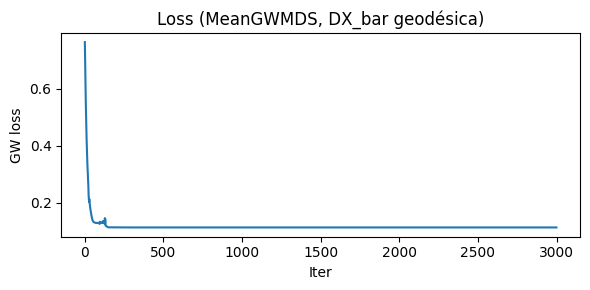

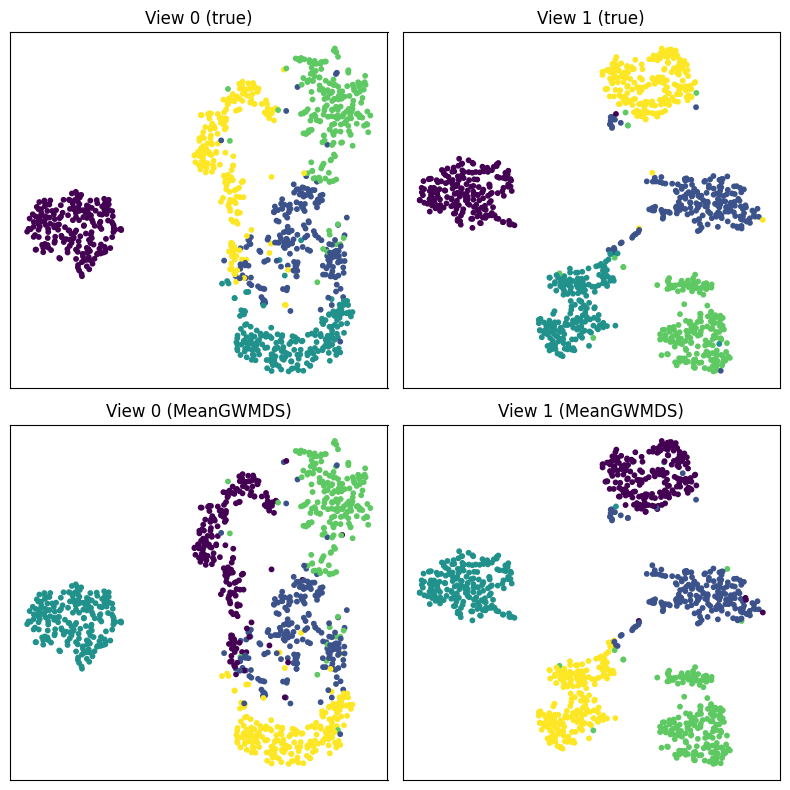

In [ ]:
# ============================================================
# MEAN-GWMDS-C (consenso por média) NO DATASET SALVO
# AGORA: DX GEODÉSICA DO ISOMAP + MÉDIA ENTRE VIEWS
# ============================================================

# ----------------------------
# CONFIG (MUDE SÓ AQUI)
# ----------------------------
DATA_PATH = "ucimultifeature_bary_gwmds.npz"
DEVICE = "cpu"

# Geodésica Isomap
USE_GEODESIC_ISOMAP = True
N_NEIGHBORS_ISOMAP = 12
DX_NORM = "mean"          # "none" | "median" | "mean" | "fro"  (recomendo "median")

# treino
N_COMPONENTS = 2
N_ITER = 3000
REG_E = 0.0
OPTIMIZER_NAME = "adam"      # "sgd" | "adam"
LEARNING_RATE = 0.02
INIT = "randn"
LEARN_PROTOTYPE_WEIGHTS = False

# Visualização
PLOT_LOSS = True
PLOT_TSNE_PER_VIEW = True
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 0

# ----------------------------
# IMPORTS
# ----------------------------
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.manifold import TSNE, Isomap


# ============================================================
# 2) CARREGAR O .NPZ SALVO
# ============================================================
data = np.load(DATA_PATH, allow_pickle=True)
labels_np = data["labels"].astype(np.int64)

Xs_np = []
i = 0
while f"X_view_{i}" in data.files:
    Xs_np.append(data[f"X_view_{i}"])
    i += 1

if len(Xs_np) == 0:
    raise ValueError("Não achei X_view_0, X_view_1, ... dentro do .npz")

K = int(data["n_classes"]) if "n_classes" in data.files else int(len(np.unique(labels_np)))

print("=== Dataset carregado do .npz ===")
print("Nº de views:", len(Xs_np))
print("Nº de amostras:", Xs_np[0].shape[0])
print("Dimensões por view:", [X.shape[1] for X in Xs_np])
print("K =", K)


# ============================================================
# 3) COMPUTAR DX GEODÉSICA POR VIEW (ISOMAP)
# ============================================================
def normalize_dx(D, mode="median", eps=1e-12):
    if mode is None or mode == "none":
        return D
    mask = ~np.eye(D.shape[0], dtype=bool)
    vals = D[mask]
    if mode == "median":
        s = np.median(vals)
    elif mode == "mean":
        s = np.mean(vals)
    elif mode == "fro":
        s = np.linalg.norm(D, ord="fro")
    else:
        raise ValueError("DX_NORM must be: 'none' | 'median' | 'mean' | 'fro'")
    return D / (s + eps)

DX_views = []
for v, Xv in enumerate(Xs_np):
    print(f"\n[Isomap] Calculando DX geodésica para view {v} | X shape={Xv.shape}")
    iso = Isomap(n_neighbors=N_NEIGHBORS_ISOMAP, n_components=2)
    iso.fit(Xv)

    if not hasattr(iso, "dist_matrix_"):
        raise AttributeError("Seu sklearn Isomap não tem 'dist_matrix_'. Atualize o scikit-learn.")

    DXv = np.asarray(iso.dist_matrix_, dtype=np.float64)

    # Se grafo desconexo → pode ter inf
    if not np.isfinite(DXv).all():
        finite_max = np.max(DXv[np.isfinite(DXv)])
        DXv[~np.isfinite(DXv)] = finite_max
        print("  Aviso: havia inf em DX (grafo desconexo). Substituí por max finito.")

    # Normaliza escala ANTES da média (crítico!)
    DXv = normalize_dx(DXv, mode=DX_NORM)

    DX_views.append(DXv)

print("\nDX geodésicas calculadas:", [D.shape for D in DX_views])


# ============================================================
# 4) MÉDIA DAS DISTÂNCIAS GEODÉSICAS ENTRE VIEWS (CONSENSO)
# ============================================================
DX_bar_np = np.mean(np.stack(DX_views, axis=0), axis=0).astype(np.float64)

# garante simetria e diagonal 0
DX_bar_np = 0.5 * (DX_bar_np + DX_bar_np.T)
np.fill_diagonal(DX_bar_np, 0.0)

print("DX_bar (média) shape:", DX_bar_np.shape)

# ============================================================
# 5) TREINAR MeanGWMDS USANDO DX_bar COMO MÉTRICA PRÉ-COMPUTADA
#    (passando lista com 1 elemento => um único T de verdade)
# ============================================================
device = torch.device(DEVICE)
labels = torch.from_numpy(labels_np).long().to(device)

DX_bar = torch.from_numpy(DX_bar_np).to(torch.float32).to(device)

model = MeanGWMDS(
    n_clusters=K,                 # ou fixe um K diferente
    n_components=N_COMPONENTS,
    reg_e=REG_E,
    init=INIT,
    optimizer_name=OPTIMIZER_NAME,
    learning_rate=LEARNING_RATE,
    precomputed_metric=True,      # IMPORTANTÍSSIMO
    learn_prototype_weights=LEARN_PROTOTYPE_WEIGHTS,
    device=DEVICE,
    normalize_dx="none", # já normalizamos antes; evita normalizar de novo
    gw_double=True
)

# aqui X = [DX_bar] (uma "view" consenso)
model.fit([DX_bar], n_iter=N_ITER)

clusters = model.get_hard_assignments(view_idx=0).detach().cpu().numpy()

# métricas
nmi = normalized_mutual_info_score(labels_np, clusters)
ari = adjusted_rand_score(labels_np, clusters)
print(f"\nNMI = {nmi:.4f} | ARI = {ari:.4f}")


# ============================================================
# 6) LOSS
# ============================================================
if PLOT_LOSS:
    plt.figure(figsize=(6, 3))
    plt.plot(model.history["loss"])
    plt.title("Loss (MeanGWMDS, DX_bar geodésica)")
    plt.xlabel("Iter")
    plt.ylabel("GW loss")
    plt.tight_layout()
    plt.show()


# ============================================================
# 7) T-SNE POR VIEW (ESTILO MV-KMeans)
#    (true em cima, pred embaixo)
# ============================================================
def tsne_2d(X, perplexity=30, seed=0):
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed
    ).fit_transform(X)

if PLOT_TSNE_PER_VIEW:
    # faz t-sne de cada view nas features originais
    X_tsne_list = [tsne_2d(Xv.astype(np.float32), perplexity=TSNE_PERPLEXITY, seed=TSNE_RANDOM_STATE)
                   for Xv in Xs_np]

    # plota só as 2 primeiras views em 2x2 (igual seu exemplo)
    if len(X_tsne_list) >= 2:
        X0, X1 = X_tsne_list[0], X_tsne_list[1]

        fig, axs = plt.subplots(2, 2, figsize=(8, 8))

        axs[0, 0].scatter(X0[:, 0], X0[:, 1], c=labels_np, s=10, cmap="viridis")
        axs[0, 0].set_title("View 0 (true)")

        axs[0, 1].scatter(X1[:, 0], X1[:, 1], c=labels_np, s=10, cmap="viridis")
        axs[0, 1].set_title("View 1 (true)")

        axs[1, 0].scatter(X0[:, 0], X0[:, 1], c=clusters, s=10, cmap="viridis")
        axs[1, 0].set_title("View 0 (MeanGWMDS)")

        axs[1, 1].scatter(X1[:, 0], X1[:, 1], c=clusters, s=10, cmap="viridis")
        axs[1, 1].set_title("View 1 (MeanGWMDS)")

        for ax in axs.ravel():
            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()
        plt.show()
    else:
        print("Há menos de 2 views; plotei nada no estilo 2x2.")


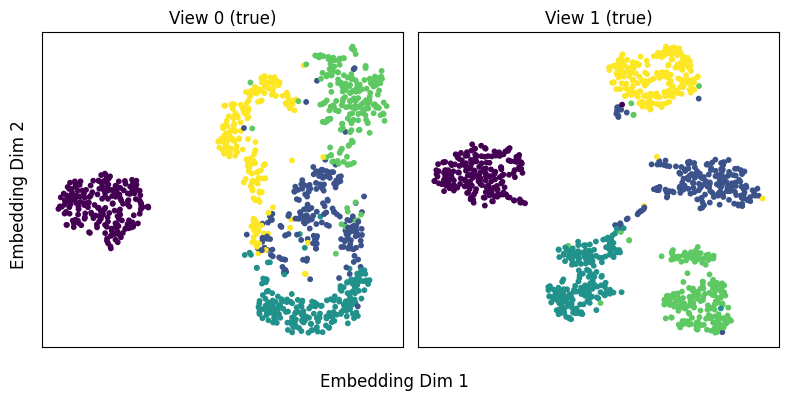

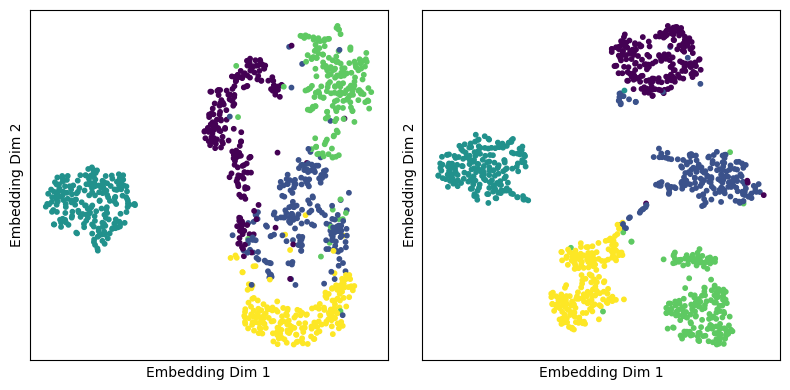

In [ ]:
# ============================================================
# 7) T-SNE POR VIEW (ESTILO MV-KMeans)
#    AGORA: duas figuras separadas
# ============================================================

def tsne_2d(X, perplexity=30, seed=0):
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed
    ).fit_transform(X)

if PLOT_TSNE_PER_VIEW:
    X_tsne_list = [
        tsne_2d(Xv.astype(np.float32),
                perplexity=TSNE_PERPLEXITY,
                seed=TSNE_RANDOM_STATE)
        for Xv in Xs_np
    ]

    if len(X_tsne_list) >= 2:
        X0, X1 = X_tsne_list[0], X_tsne_list[1]

        # ====================================================
        # FIGURA 1 — LABELS VERDADEIROS (LINHA DE CIMA)
        # ====================================================
        fig1, axs1 = plt.subplots(1, 2, figsize=(8, 4))

        axs1[0].scatter(X0[:, 0], X0[:, 1],
                        c=labels_np, s=10, cmap="viridis")
        axs1[0].set_title("View 0 (true)")

        axs1[1].scatter(X1[:, 0], X1[:, 1],
                        c=labels_np, s=10, cmap="viridis")
        axs1[1].set_title("View 1 (true)")

        for ax in axs1:
            ax.set_xticks([])
            ax.set_yticks([])

        fig1.supxlabel("Embedding Dim 1")
        fig1.supylabel("Embedding Dim 2")

        plt.tight_layout()
        plt.show()

        # ====================================================
        # FIGURA 2 — CLUSTERS (LINHA DE BAIXO)
        # ====================================================
        fig2, axs2 = plt.subplots(1, 2, figsize=(8, 4))

        axs2[0].scatter(X0[:, 0], X0[:, 1],
                        c=clusters, s=10, cmap="viridis")
        # axs2[0].set_title("View 0 (MeanGWMDS)")

        axs2[1].scatter(X1[:, 0], X1[:, 1],
                        c=clusters, s=10, cmap="viridis")
        # axs2[1].set_title("View 1 (MeanGWMDS)")

        for ax in axs2:
               ax.set_xlabel("Embedding Dim 1")
               ax.set_ylabel("Embedding Dim 2")
               ax.set_xticks([])
               ax.set_yticks([])



        plt.tight_layout()
        plt.savefig('Mean-GWMDS-C.pdf', format='pdf')

        plt.show()

    else:
        print("Há menos de 2 views; plotei nada no estilo 1x2.")
